# LIB

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import tensorflow as tf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.ensemble import StackingRegressor
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency
from statsmodels.formula.api import ols
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from scipy.stats import ttest_rel
import shap
import lightgbm as lgb
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from scipy.stats import mannwhitneyu

# Data import

In [47]:
train_df = pd.read_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Train_Data.csv')
test_df = pd.read_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Test_Data.csv')

train_final_imputation = pd.read_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Train_final_imputation.csv')
test_final_imputation = pd.read_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Test_final_imputation.csv')

train_final_no_imputation = pd.read_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Train_final_no_imputation.csv')
test_final_no_imputation = pd.read_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Test_final_no_imputation.csv')

# With Imp

In [48]:
# Target
y_train = train_df['BI_post_int']
y_test = test_df['BI_post_int']

# Features
X_train = train_final_imputation  
X_test = test_final_imputation   

In [49]:
y_test

0       95.0
1      100.0
2       98.0
3       98.0
4       93.0
       ...  
310     95.0
311     97.0
312     97.0
313     65.0
314     95.0
Name: BI_post_int, Length: 315, dtype: float64

## Correlazione con la target

C:\Users\fccat\AppData\Local\Temp\ipykernel_13368\3242189895.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.index, y=corr_target.values, palette="coolwarm")


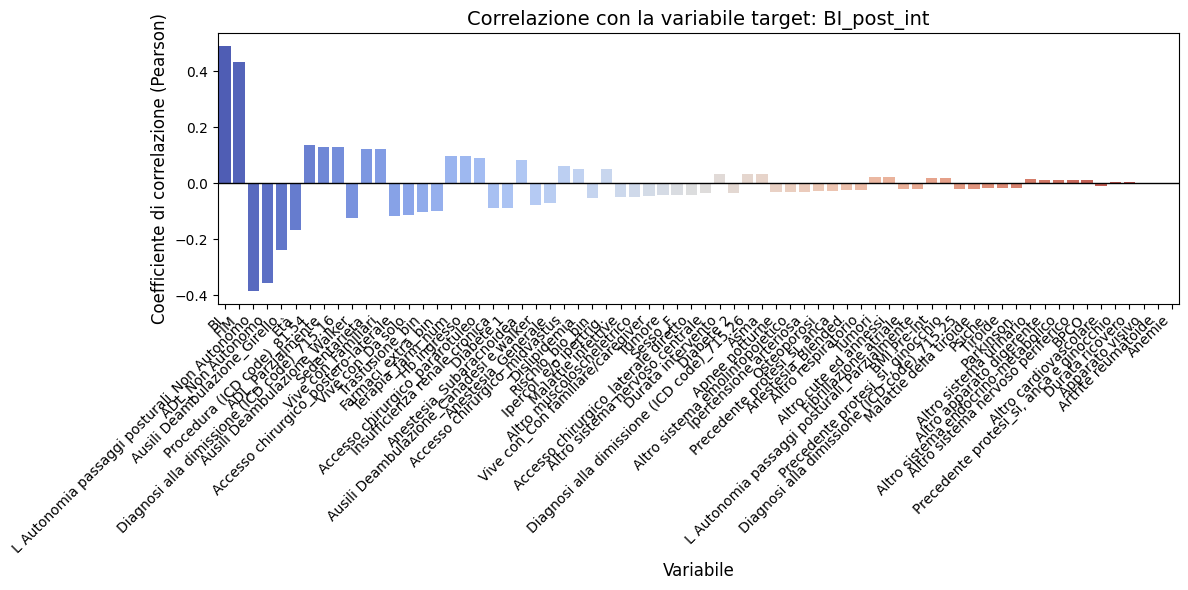

In [50]:

# Unisci X_train e y_train
df_corr = pd.concat([X_train, y_train.rename("BI_post_int")], axis=1)

# Calcola correlazione solo con la variabile target
corr_target = df_corr.corr()["BI_post_int"].drop("BI_post_int")

# Ordina per valore assoluto
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)

# Grafico verticale
plt.figure(figsize=(12, 6))
sns.barplot(x=corr_target.index, y=corr_target.values, palette="coolwarm")
plt.axhline(0, color='black', lw=1)
plt.title("Correlazione con la variabile target: BI_post_int", fontsize=14)
plt.ylabel("Coefficiente di correlazione (Pearson)", fontsize=12)
plt.xlabel("Variabile", fontsize=12)
plt.xticks(rotation=45, ha='right')  # ruota le etichette per leggerle
plt.tight_layout()
plt.show()

C:\Users\fccat\AppData\Local\Temp\ipykernel_13368\4015558337.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


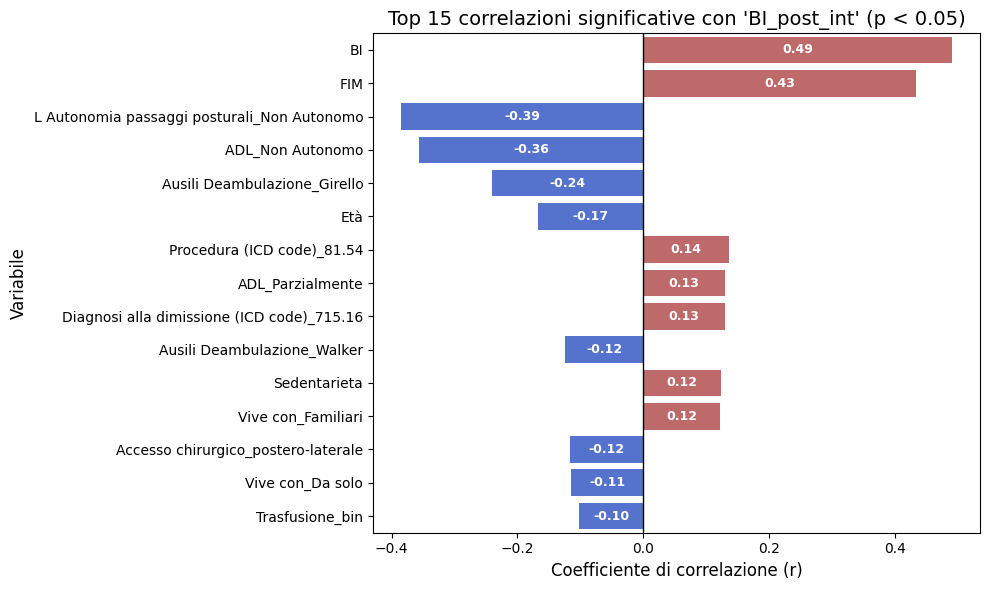

In [51]:
# Unisci X_train e y_train
df_corr = pd.concat([X_train, y_train.rename("BI_post_int")], axis=1)
target = "BI_post_int"

# Calcola correlazione e p-value
corr_list = []
for col in X_train.columns:
    r, p = pearsonr(df_corr[col], df_corr[target])
    corr_list.append((col, r, p))

corr_df = pd.DataFrame(corr_list, columns=["Variabile", "r", "p_value"])

# Filtra solo correlazioni significative (p < 0.05)
p_cutoff = 0.05
corr_df_sig = corr_df[corr_df["p_value"] < p_cutoff]

# Mostra top N correlazioni per valore assoluto
top_n = 15
corr_df_sig = corr_df_sig.reindex(corr_df_sig["r"].abs().sort_values(ascending=False).head(top_n).index)

# Colori invertiti: rosso = positiva, blu = negativa
colors = ["indianred" if x > 0 else "royalblue" for x in corr_df_sig["r"]]

# Grafico orizzontale
plt.figure(figsize=(10, 6))
bars = sns.barplot(
    x="r",
    y="Variabile",
    data=corr_df_sig,
    palette=colors
)
plt.axvline(0, color='black', lw=1)
plt.title(f"Top {top_n} correlazioni significative con '{target}' (p < {p_cutoff})", fontsize=14)
plt.xlabel("Coefficiente di correlazione (r)", fontsize=12)
plt.ylabel("Variabile", fontsize=12)

# Aggiungi valori r dentro le barre
for bar, r_val in zip(bars.patches, corr_df_sig["r"]):
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    x_pos = width / 2
    bars.text(
        x=x_pos,
        y=y_pos,
        s=f"{r_val:.2f}",
        ha='center',
        va='center',
        color='white',  # bianco per contrasto con i colori scuri
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

## Ridge

In [52]:
# Definizione del modello Ridge

ridge = Ridge(random_state=42)

# Grid dei parametri alpha
param_grid = {
    'alpha': [0, 0.01, 0.1, 1, 10, 100]
}

# GridSearch con 5-fold CV sul train set
grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search.fit(X_train, y_train)

# Visualizzare i risultati dettagliati per ogni alpha
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nRisultati della cross-validation per ogni alpha:")
print(cv_results[['param_alpha', 'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params = grid_search.best_params_
print("\nMigliori hyper-parametri:", best_params)
print("Miglior punteggio CV (R²):", grid_search.best_score_)

# Modello finale con i migliori parametri
best_ridge = grid_search.best_estimator_

# Predizioni sul test set
y_pred_ridge = best_ridge.predict(X_test)

# Funzione di valutazione
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    # Conversione sicura in numpy array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    # Metriche principali
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    # Bootstrap
    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    # Risultati
    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }
# Valutazione finale
evaluate_model_with_ci(y_test, y_pred_ridge, "Ridge Regression (GridSearchCV)")


Risultati della cross-validation per ogni alpha:
   param_alpha  mean_test_score  std_test_score  mean_train_score  \
0         0.00    -1.572833e+26    2.700178e+26          0.400700   
1         0.01     2.247876e-01    1.282288e-01          0.401198   
2         0.10     2.318471e-01    1.253893e-01          0.400904   
3         1.00     2.530607e-01    1.174222e-01          0.395057   
4        10.00     2.694132e-01    9.714062e-02          0.370161   
5       100.00     2.815211e-01    8.104586e-02          0.330528   

   std_train_score  
0         0.022142  
1         0.022306  
2         0.022311  
3         0.022525  
4         0.021367  
5         0.018199  

Migliori hyper-parametri: {'alpha': 100}
Miglior punteggio CV (R²): 0.2815210846505665

Ridge Regression (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.69  [2.30, 3.20]
  RMSE       = 4.85  [3.23, 6.72]
  R²         = 0.295  [0.140, 0.431]
  SD(target) = 5.77
  MAE/SD     = 0

{'MAE': 2.6927616713142166,
 'MAE_CI': array([2.30469896, 3.19728241]),
 'RMSE': np.float64(4.8469534777044),
 'RMSE_CI': array([3.22814745, 6.72152733]),
 'R2': 0.2947506885701837,
 'R2_CI': array([0.13989831, 0.4311041 ]),
 'SD_target': np.float64(5.771617158635033),
 'MAE/SD': np.float64(0.46655237125101434),
 'RMSE/SD': np.float64(0.8397912308602754)}

In [53]:
# Ottieni i coefficienti e associarli alle feature
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_ridge.coef_
}).sort_values(by='Coefficient', key=np.abs, ascending=False)

print(coef_df)
# Feature importance basata sui coefficienti del modello Ridge
top_features = coef_df.head(5)
for i, row in top_features.iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.3f}")

                                        Feature  Coefficient
64                                           BI     1.906958
18  L Autonomia passaggi posturali_Non Autonomo    -1.187431
21                 Ausili Deambulazione_Girello    -0.716199
19  L Autonomia passaggi posturali_Parzialmente     0.679235
65                                          FIM     0.583704
..                                          ...          ...
55                                    Parkinson     0.014705
61                                  BMI Pre-Int    -0.014163
28             Precedente protesi_si, ginocchio    -0.011841
31                        Altro cute ed annessi     0.005611
51                       Ipertensione arteriosa     0.002014

[68 rows x 2 columns]
BI: 1.907
L Autonomia passaggi posturali_Non Autonomo: -1.187
Ausili Deambulazione_Girello: -0.716
L Autonomia passaggi posturali_Parzialmente: 0.679
FIM: 0.584


## Lasso

In [54]:

# ===============================
# 1️⃣ Definizione del modello Lasso
# ===============================
lasso = Lasso(random_state=42, max_iter=10000)  # max_iter alto per garantire convergenza

# Grid dei parametri alpha
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

# ===============================
# 2️⃣ GridSearchCV con 5-fold CV sul train set
# ===============================
grid_search = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search.fit(X_train, y_train)

# ===============================
# 3️⃣ Visualizzare i risultati della cross-validation
# ===============================
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nRisultati della cross-validation per ogni alpha:")
print(cv_results[['param_alpha', 'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params = grid_search.best_params_
print("\nMigliori hyper-parametri:", best_params)
print("Miglior punteggio CV (R²):", grid_search.best_score_)

# ===============================
# 4️⃣ Modello finale e predizione
# ===============================
best_lasso = grid_search.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

# ===============================
# 5️⃣ Funzione di valutazione (stessa della tua)
# ===============================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ===============================
# 6️⃣ Valutazione finale
# ===============================
evaluate_model_with_ci(y_test, y_pred_lasso, "Lasso Regression (GridSearchCV)")



Risultati della cross-validation per ogni alpha:
   param_alpha  mean_test_score  std_test_score  mean_train_score  \
0       0.0001         0.224739        0.128156          0.401195   
1       0.0010         0.231958        0.123674          0.400448   
2       0.0100         0.277493        0.099228          0.381009   
3       0.1000         0.274722        0.075113          0.310642   
4       1.0000         0.201093        0.021506          0.209527   
5      10.0000        -0.001787        0.001532          0.000000   

   std_train_score  
0         0.022306  
1         0.022355  
2         0.023023  
3         0.017709  
4         0.012220  
5         0.000000  

Migliori hyper-parametri: {'alpha': 0.01}
Miglior punteggio CV (R²): 0.2774927158539328

Lasso Regression (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.75  [2.36, 3.23]
  RMSE       = 4.88  [3.42, 6.68]
  R²         = 0.284  [0.086, 0.413]
  SD(target) = 5.77
  MAE/SD     = 

{'MAE': 2.753014592244489,
 'MAE_CI': array([2.36217003, 3.23424715]),
 'RMSE': np.float64(4.884101431627043),
 'RMSE_CI': array([3.41513657, 6.68069326]),
 'R2': 0.2838989383311683,
 'R2_CI': array([0.08645685, 0.41299342]),
 'SD_target': np.float64(5.771617158635033),
 'MAE/SD': np.float64(0.4769918926666243),
 'RMSE/SD': np.float64(0.8462275472169598)}

In [55]:
# Ottieni i coefficienti e associarli alle feature
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lasso.coef_
}).sort_values(by='Coefficient', key=np.abs, ascending=False)

print(coef_df)


# # Feature importance basata sui coefficienti del modello Lasso
top_features = coef_df.head(5)
for i, row in top_features.iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.3f}")

                                        Feature  Coefficient
21                 Ausili Deambulazione_Girello   -10.267530
18  L Autonomia passaggi posturali_Non Autonomo    -2.976400
22                  Ausili Deambulazione_Walker    -2.124538
45                                    Diabete 1    -2.090739
64                                           BI     2.052523
..                                          ...          ...
36               Altro sistema nervoso centrale     0.000000
59                                       Tumori     0.000000
58                                       Tumore    -0.000000
57                                      Tiroide    -0.000000
55                                    Parkinson     0.000000

[68 rows x 2 columns]
Ausili Deambulazione_Girello: -10.268
L Autonomia passaggi posturali_Non Autonomo: -2.976
Ausili Deambulazione_Walker: -2.125
Diabete 1: -2.091
BI: 2.053


## Random Forest

In [56]:
# Definizione del modello base
rf_reg = RandomForestRegressor(random_state=42)

# Definizione del grid dei parametri da testare
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearch con 5-fold CV sul train set
grid_search = GridSearchCV(
    estimator=rf_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',  # puoi usare anche 'neg_mean_absolute_error'
    n_jobs=-1
)

# Fit del GridSearch sul train set
grid_search.fit(X_train, y_train)

# Migliori parametri trovati
best_params = grid_search.best_params_
print("Best Hyper-parameters:", best_params)

# Creiamo il modello finale con i migliori parametri
best_rf = grid_search.best_estimator_

# Predizioni sul test set
y_pred_rf = best_rf.predict(X_test)

# Funzione di valutazione
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    # Conversione sicura in numpy array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    # Metriche principali
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    # Bootstrap
    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    # Risultati
    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# Valutazione del modello ottimizzato
evaluate_model_with_ci(y_test, y_pred_rf, "Random Forest Regressor (GridSearchCV)")

Best Hyper-parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}

Random Forest Regressor (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.45  [2.05, 2.95]
  RMSE       = 4.73  [3.06, 6.67]
  R²         = 0.328  [0.132, 0.528]
  SD(target) = 5.77
  MAE/SD     = 0.424
  RMSE/SD    = 0.820


{'MAE': 2.448288919570786,
 'MAE_CI': array([2.05220863, 2.94661666]),
 'RMSE': np.float64(4.732781355079121),
 'RMSE_CI': array([3.05905921, 6.66799175]),
 'R2': 0.3275842907239974,
 'R2_CI': array([0.13154051, 0.52831851]),
 'SD_target': np.float64(5.771617158635033),
 'MAE/SD': np.float64(0.42419461517953444),
 'RMSE/SD': np.float64(0.8200095787708842)}

                                        feature  importance
0                                            BI    0.503721
1                                           Età    0.064690
2                             Durata intervento    0.058811
3                                   Hb ingresso    0.047369
4                                           FIM    0.043262
5                               Durata ricovero    0.042008
6                                   BMI Pre-Int    0.035157
7                  Insufficienza renale cronica    0.022712
8   L Autonomia passaggi posturali_Non Autonomo    0.015556
9                              Terapia_farm_num    0.012350
10                   Procedura (ICD code)_81.54    0.008560
11                                      Sesso_F    0.007882
12                            Farmaci_extra_bin    0.007678
13             Vive con_Con familiare/caregiver    0.006855
14                              Trasfusione_bin    0.006823


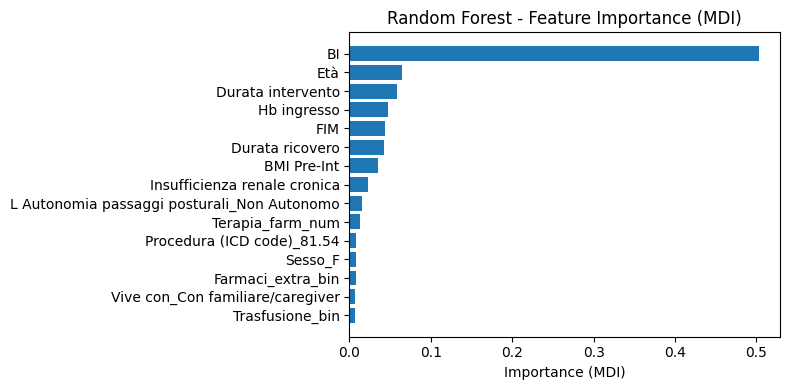

In [57]:
# Assumiamo che X_train_drop e X_test_drop siano DataFrame con colonne originali
feature_names = X_train.columns.tolist()

# best_rf è il modello preso da GridSearchCV (come nel tuo codice)
mdi_importances = best_rf.feature_importances_

# DataFrame ordinato
mdi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mdi_importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Mostra le prime 15
print(mdi_df.head(15))


# Grafico orizzontale top 15
top_n = 15
plt.figure(figsize=(8, max(4, 0.25*top_n)))
plt.barh(mdi_df['feature'].head(top_n)[::-1], mdi_df['importance'].head(top_n)[::-1])
plt.xlabel('Importance (MDI)')
plt.title('Random Forest - Feature Importance (MDI)')
plt.tight_layout()
plt.show()

Expected value (base prediction): 95.865


C:\Users\fccat\AppData\Local\Temp\ipykernel_13368\3289546023.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_top, X_test_top)


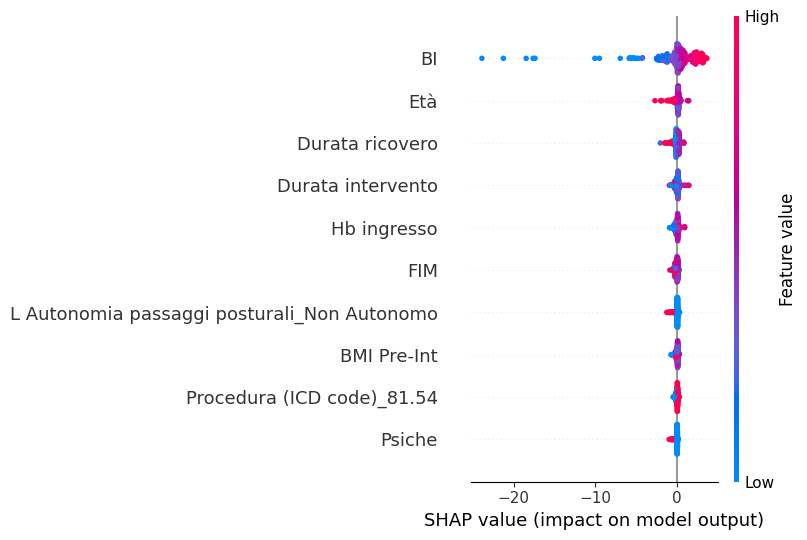

In [58]:
# 1. Crea un oggetto explainer specifico per modelli tree-based
explainer = shap.TreeExplainer(best_rf)

# 2. Calcola i valori SHAP (quanto ciascuna feature contribuisce alla predizione per ogni campione)
shap_values = explainer.shap_values(X_test)

# 3. Ottieni anche i valori predetti e la base line (expected value)
expected_value = explainer.expected_value
print(f"Expected value (base prediction): {np.ravel(expected_value)[0]:.3f}")


# Calcola l'importanza media assoluta di ogni feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Crea un DataFrame per ordinarle
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False)

# Seleziona le prime 10 feature più importanti
top_features = shap_importance['feature'].head(10).tolist()

# Filtra i dati SHAP e X_test sulle prime 10 feature
shap_values_top = shap_values[:, [X_test.columns.get_loc(f) for f in top_features]]
X_test_top = X_test[top_features]

# Plot con solo le prime 10
shap.summary_plot(shap_values_top, X_test_top)

## LightGBM

In [59]:
# ----------------------------
# Pulizia dei nomi delle colonne (fondamentale per LightGBM)
# ----------------------------
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

# ----------------------------
# Definizione del modello
# ----------------------------
lgb_reg = lgb.LGBMRegressor(random_state=42)

# ----------------------------
# Grid dei parametri da testare
# ----------------------------
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [-1, 5, 10, 20],          # -1 = nessun limite
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100],
    'min_child_samples': [5, 10, 20]
}

# ----------------------------
# GridSearchCV con 5-fold CV
# ----------------------------
grid_search = GridSearchCV(
    estimator=lgb_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    error_score='raise'  # mostra l’errore esatto in caso di fallimento
)

# ----------------------------
# Fit sul train set (con gestione errori)
# ----------------------------
try:
    grid_search.fit(X_train, y_train)
except Exception as e:
    print("❌ Errore durante il fit di GridSearchCV:")
    print(e)
    raise

# ----------------------------
# Migliori parametri trovati
# ----------------------------
best_params = grid_search.best_params_
print("\n✅ Best Hyper-parameters LightGBM:", best_params)

# ----------------------------
# Modello finale con i migliori parametri
# ----------------------------
best_lgb = grid_search.best_estimator_

# ----------------------------
# Predizioni sul test set
# ----------------------------
y_pred_lgb = best_lgb.predict(X_test)

# ----------------------------
# Valutazione con bootstrap CI
# ----------------------------
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n📊 {name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ----------------------------
# Valutazione finale LightGBM
# ----------------------------
evaluate_model_with_ci(y_test, y_pred_lgb, "LightGBM Regressor (GridSearchCV)")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,001535 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 472
[LightGBM] [Info] Number of data points in the train set: 1257, number of used features: 55
[LightGBM] [Info] Start training from score 95,859984
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

{'MAE': 2.5038741245644744,
 'MAE_CI': array([2.118603  , 2.99825381]),
 'RMSE': np.float64(4.687476976359384),
 'RMSE_CI': array([3.15208844, 6.70423696]),
 'R2': 0.34039602610414976,
 'R2_CI': array([0.11431257, 0.54941209]),
 'SD_target': np.float64(5.771617158635033),
 'MAE/SD': np.float64(0.4338254003591312),
 'RMSE/SD': np.float64(0.8121600666714969)}

Top 10 features (LightGBM - gain):
                                        feature  importance
64                                           BI         858
65                                          FIM         344
60                                          Et_         333
63                            Durata_intervento         309
62                              Durata_ricovero         247
66                                  Hb_ingresso         246
8                     Procedura_ICD_code__81_54         160
61                                  BMI_Pre_Int         155
15                      Anestesia_Subaracnoidea         134
18  L_Autonomia_passaggi_posturali_Non_Autonomo         116


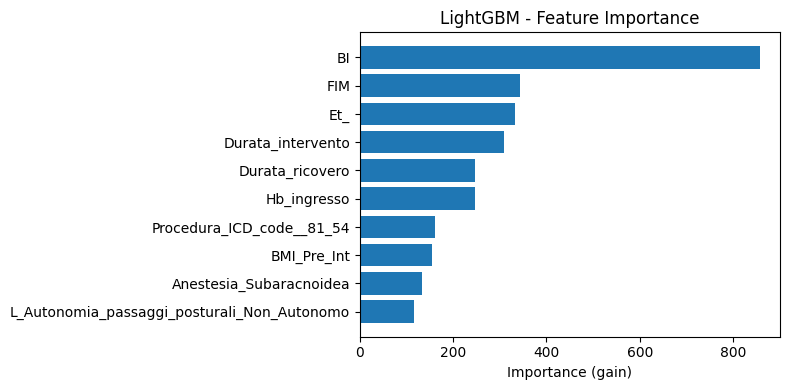

In [60]:
# ----------------------------
# Feature importance basata sul gain
# ----------------------------
gain_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_lgb.feature_importances_  # default è "split", ma puoi usare best_lgb.booster_.feature_importance('gain') per il gain
}).sort_values('importance', ascending=False)

print("Top 10 features (LightGBM - gain):")
print(gain_importance.head(10))

# Grafico
top_n = 10
plt.figure(figsize=(8, max(4, 0.25*top_n)))
plt.barh(gain_importance['feature'].head(top_n)[::-1], gain_importance['importance'].head(top_n)[::-1])
plt.xlabel('Importance (gain)')
plt.title('LightGBM - Feature Importance')
plt.tight_layout()
plt.show()


Top 10 features (SHAP):
                                        feature  mean_abs_shap
64                                           BI       1.511705
8                     Procedura_ICD_code__81_54       0.260840
18  L_Autonomia_passaggi_posturali_Non_Autonomo       0.226004
60                                          Et_       0.183644
65                                          FIM       0.171496
62                              Durata_ricovero       0.157586
63                            Durata_intervento       0.129472
66                                  Hb_ingresso       0.125427
16                             ADL_Non_Autonomo       0.095722
15                      Anestesia_Subaracnoidea       0.088766


C:\Users\fccat\AppData\Local\Temp\ipykernel_13368\894026613.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_top, X_test_top)  # valori SHAP per singolo sample


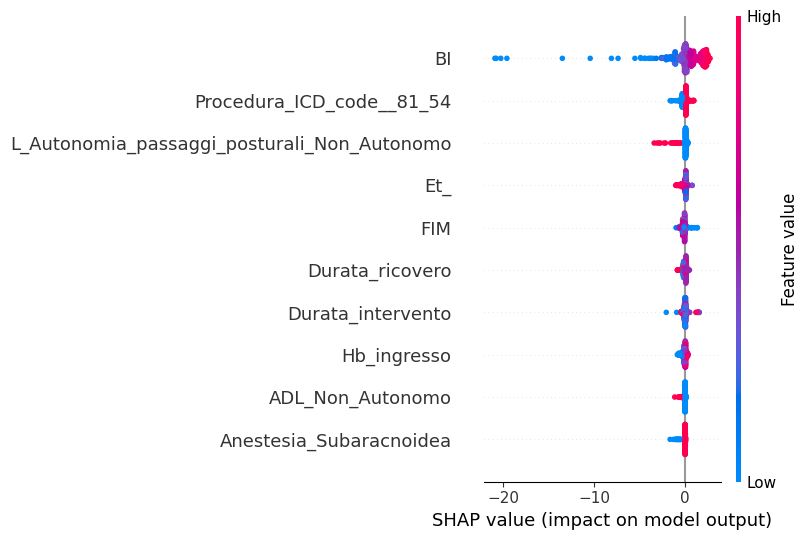

In [61]:

# 1️⃣ Crea l’explainer
explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_test)

# 2️⃣ Importanza globale media assoluta
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False)

print("Top 10 features (SHAP):")
print(shap_importance.head(10))

# 3️⃣ Grafico top 10
top_features = shap_importance['feature'].head(10).tolist()
shap_values_top = shap_values[:, [X_test.columns.get_loc(f) for f in top_features]]
X_test_top = X_test[top_features]

shap.summary_plot(shap_values_top, X_test_top)  # valori SHAP per singolo sample


## Decision Tree

In [62]:
# ===============================
# 1️⃣ Definizione del modello Decision Tree
# ===============================
dt_reg = DecisionTreeRegressor(random_state=42)

# Grid dei parametri da testare
param_grid = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# ===============================
# 2️⃣ GridSearchCV con 5-fold CV sul train set
# ===============================
grid_search = GridSearchCV(
    estimator=dt_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',  # puoi cambiare in 'neg_mean_absolute_error' se preferisci
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search.fit(X_train, y_train)

# ===============================
# 3️⃣ Visualizzare i risultati della cross-validation
# ===============================
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nRisultati della cross-validation per ogni combinazione di iperparametri:")
print(cv_results[['param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf',
                  'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params = grid_search.best_params_
print("\nMigliori hyper-parametri:", best_params)
print("Miglior punteggio CV (R²):", grid_search.best_score_)

# ===============================
# 4️⃣ Modello finale e predizione
# ===============================
best_dt = grid_search.best_estimator_
y_pred_dt = best_dt.predict(X_test)

# ===============================
# 5️⃣ Funzione di valutazione (stessa tua)
# ===============================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ===============================
# 6️⃣ Valutazione finale
# ===============================
evaluate_model_with_ci(y_test, y_pred_dt, "Decision Tree Regressor (GridSearchCV)")


Risultati della cross-validation per ogni combinazione di iperparametri:
   param_max_depth  param_min_samples_split  param_min_samples_leaf  \
0             None                        2                       1   
1             None                        5                       1   
2             None                       10                       1   
3             None                        2                       2   
4             None                        5                       2   
5             None                       10                       2   
6             None                        2                       4   
7             None                        5                       4   
8             None                       10                       4   
9                5                        2                       1   
10               5                        5                       1   
11               5                       10                       1   
12 

{'MAE': 2.5578553976530825,
 'MAE_CI': array([2.13062197, 3.07459238]),
 'RMSE': np.float64(5.09204927093557),
 'RMSE_CI': array([3.336357 , 7.1579859]),
 'R2': 0.22162269863739303,
 'R2_CI': array([-0.08989779,  0.48585797]),
 'SD_target': np.float64(5.771617158635033),
 'MAE/SD': np.float64(0.44317828562593126),
 'RMSE/SD': np.float64(0.8822569361374312)}

                                       feature  importance
0                                           BI    0.709258
1                                          Et_    0.087558
2                             Terapia_farm_num    0.064254
3  L_Autonomia_passaggi_posturali_Non_Autonomo    0.058061
4                    Procedura_ICD_code__81_54    0.031133
5                            Durata_intervento    0.017124
6                                          FIM    0.012565
7                                  BMI_Pre_Int    0.007545
8                     Altro_muscoloscheletrico    0.007329
9                      Anestesia_Subaracnoidea    0.003296


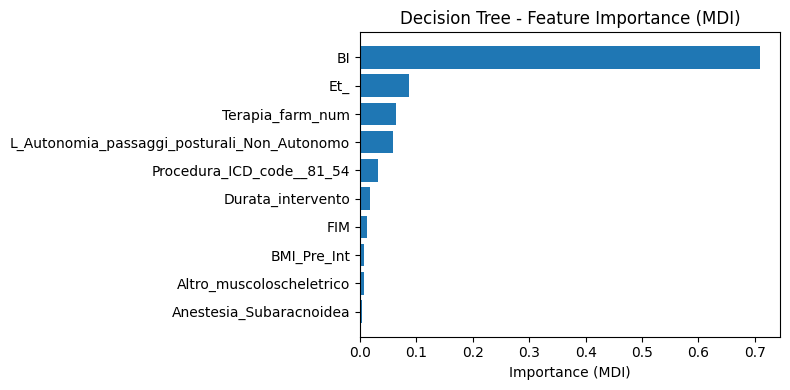

In [63]:
# Assumiamo che X_train_drop e X_test_drop siano DataFrame con colonne originali
feature_names = X_train.columns.tolist()

# best_dt è il modello preso da GridSearchCV 
mdi_importances = best_dt.feature_importances_

# DataFrame ordinato
mdi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mdi_importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Mostra le prime 15
print(mdi_df.head(10))


# Grafico orizzontale top 15
top_n = 10
plt.figure(figsize=(8, max(4, 0.25*top_n)))
plt.barh(mdi_df['feature'].head(top_n)[::-1], mdi_df['importance'].head(top_n)[::-1])
plt.xlabel('Importance (MDI)')
plt.title('Decision Tree - Feature Importance (MDI)')
plt.tight_layout()
plt.show()

Expected value (base prediction): 95.860
Top 10 features (SHAP):
                                        feature  mean_abs_shap
64                                           BI       1.772513
8                     Procedura_ICD_code__81_54       0.441810
60                                          Et_       0.305407
18  L_Autonomia_passaggi_posturali_Non_Autonomo       0.163602
65                                          FIM       0.121095
67                             Terapia_farm_num       0.077801
63                            Durata_intervento       0.075115
32                     Altro_muscoloscheletrico       0.047142
15                      Anestesia_Subaracnoidea       0.045745
61                                  BMI_Pre_Int       0.022387


C:\Users\fccat\AppData\Local\Temp\ipykernel_13368\2244922468.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_top, X_test_top)


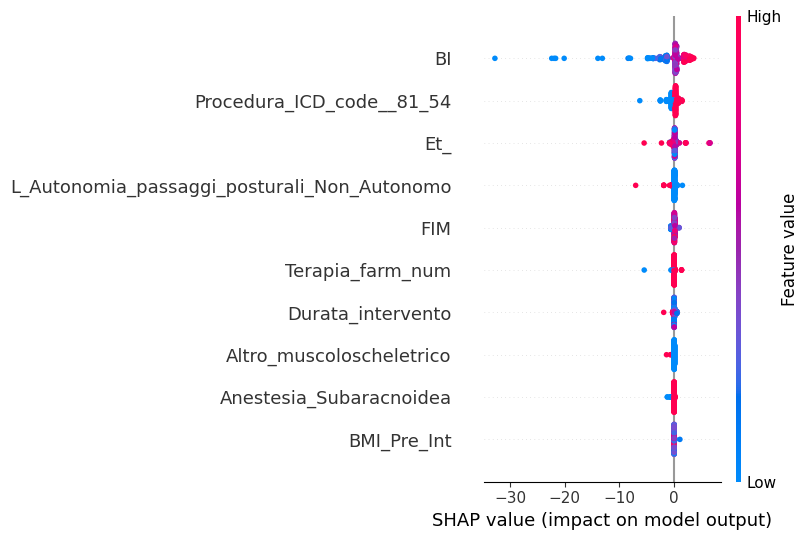

In [64]:
# 1. Crea un oggetto explainer specifico per modelli tree-based
explainer = shap.TreeExplainer(best_dt)

# 2. Calcola i valori SHAP (quanto ciascuna feature contribuisce alla predizione per ogni campione)
shap_values = explainer.shap_values(X_test)

# 3. Ottieni anche i valori predetti e la base line (expected value)
expected_value = explainer.expected_value
print(f"Expected value (base prediction): {np.ravel(expected_value)[0]:.3f}")


# Calcola l'importanza media assoluta di ogni feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Crea un DataFrame per ordinarle
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False)

# Seleziona le prime 10 feature più importanti
top_features = shap_importance['feature'].head(10).tolist()

# Filtra i dati SHAP e X_test sulle prime 10 feature
shap_values_top = shap_values[:, [X_test.columns.get_loc(f) for f in top_features]]
X_test_top = X_test[top_features]
print("Top 10 features (SHAP):")
print(shap_importance.head(10))
# Plot con solo le prime 10
shap.summary_plot(shap_values_top, X_test_top)

## SVM

In [65]:


# ===============================
# 1️⃣ Definizione del modello SVR
# ===============================
svr = SVR()

# Grid dei parametri da testare
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1],
    'degree': [2, 3, 4]  # utile solo per kernel='poly'
}

# ===============================
# 2️⃣ GridSearchCV con 5-fold CV sul train set
# ===============================
grid_search_svr = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search_svr.fit(X_train, y_train)

# ===============================
# 3️⃣ Visualizzare i risultati della cross-validation
# ===============================
cv_results_svr = pd.DataFrame(grid_search_svr.cv_results_)
print("\nRisultati della cross-validation per ogni combinazione di parametri:")
print(cv_results_svr[['param_kernel', 'param_C', 'param_epsilon', 'param_degree',
                      'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params_svr = grid_search_svr.best_params_
print("\nMigliori hyper-parametri:", best_params_svr)
print("Miglior punteggio CV (R²):", grid_search_svr.best_score_)

# ===============================
# 4️⃣ Modello finale e predizione
# ===============================
best_svr = grid_search_svr.best_estimator_
y_pred_svr = best_svr.predict(X_test)

# ===============================
# 5️⃣ Funzione di valutazione con CI (stessa che usi per RF e Lasso)
# ===============================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ===============================
# 6️⃣ Valutazione finale
# ===============================
evaluate_model_with_ci(y_test, y_pred_svr, "Support Vector Regressor (GridSearchCV)")



Risultati della cross-validation per ogni combinazione di parametri:
    param_kernel  param_C  param_epsilon  param_degree  mean_test_score  \
0         linear      0.1           0.01             2         0.185340   
1           poly      0.1           0.01             2         0.150832   
2            rbf      0.1           0.01             2         0.069032   
3        sigmoid      0.1           0.01             2         0.129178   
4         linear      0.1           0.10             2         0.186467   
..           ...      ...            ...           ...              ...   
187      sigmoid    100.0           0.50             4     -7439.545903   
188       linear    100.0           1.00             4         0.214066   
189         poly    100.0           1.00             4        -0.285199   
190          rbf    100.0           1.00             4         0.207028   
191      sigmoid    100.0           1.00             4     -7399.716190   

     std_test_score  mean_tra

{'MAE': 2.555467183500939,
 'MAE_CI': array([2.16732335, 3.08936379]),
 'RMSE': np.float64(4.790778782593592),
 'RMSE_CI': array([3.1848518 , 6.72338556]),
 'R2': 0.3110032025953491,
 'R2_CI': array([0.11709032, 0.48283538]),
 'SD_target': np.float64(5.771617158635033),
 'MAE/SD': np.float64(0.44276449966499476),
 'RMSE/SD': np.float64(0.8300583096413474)}

Top 10 Feature Importance (Permutation):
BI: 0.3037
L_Autonomia_passaggi_posturali_Non_Autonomo: 0.0347
Accesso_chirurgico_postero_laterale: 0.0346
FIM: 0.0287
Durata_ricovero: 0.0279
Hb_ingresso: 0.0232
L_Autonomia_passaggi_posturali_Parzialmente: 0.0211
Et_: 0.0200
ADL_Non_Autonomo: 0.0167
Ausili_Deambulazione_Walker: 0.0118


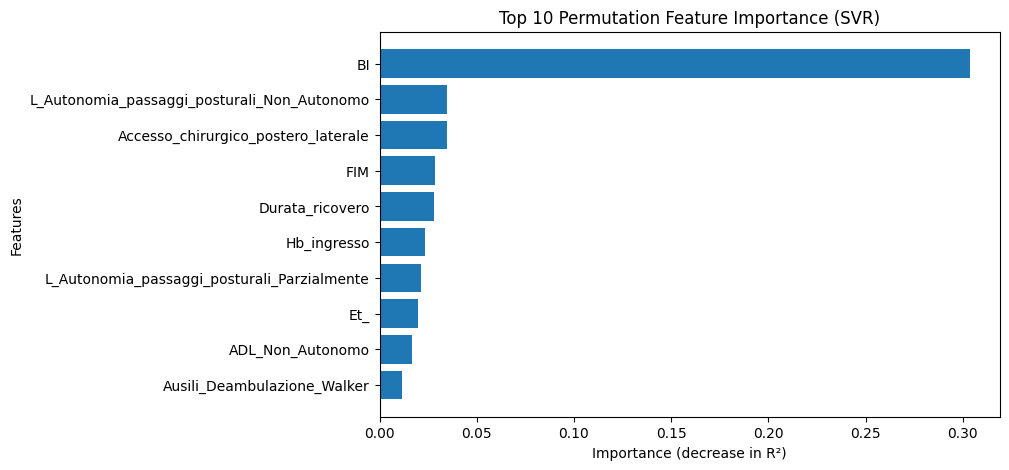

In [66]:
# Calcola la Permutation Importance sul test set
perm_importance = permutation_importance(
    best_svr, X_test, y_test, n_repeats=30, random_state=42, scoring='r2'
)

# Ordina per importanza (decrescente)
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

# Seleziona le prime 10 feature
top_n = 10
top_idx = sorted_idx[:top_n]

# Stampa le top 10 feature
print("Top 10 Feature Importance (Permutation):")
for i in top_idx:
    print(f"{X_test.columns[i]}: {perm_importance.importances_mean[i]:.4f}")

# Grafico con le top 10
plt.figure(figsize=(8, 5))
plt.barh(X_test.columns[top_idx][::-1], perm_importance.importances_mean[top_idx][::-1])
plt.xlabel("Importance (decrease in R²)")
plt.ylabel("Features")
plt.title("Top 10 Permutation Feature Importance (SVR)")
plt.show()


## MLP

In [67]:
# =======================================
# 1️⃣ Import librerie aggiornate
# =======================================
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from scikeras.wrappers import KerasRegressor  # ✅ sostituisce il vecchio wrapper
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# =======================================
# 2️⃣ Funzione per costruire il modello
# =======================================
def build_model(n_hidden=2, n_neurons=64, dropout_rate=0.2, lr=0.001, optimizer='adam'):
    model = Sequential()
    model.add(Dense(n_neurons, input_dim=X_train.shape[1], activation='relu'))
    
    for _ in range(n_hidden - 1):
        model.add(Dense(n_neurons, activation='relu'))
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1, activation='linear'))

    if optimizer == 'adam':
        opt = Adam(learning_rate=lr)
    else:
        opt = RMSprop(learning_rate=lr)
        
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

# =======================================
# 3️⃣ Wrapping con scikeras
# =======================================
keras_reg = KerasRegressor(
    model=build_model,
    verbose=0
)

# =======================================
# 4️⃣ Ricerca iperparametri
# =======================================
param_dist = {
    "model__n_hidden": [1, 2, 3],
    "model__n_neurons": [32, 64, 128],
    "model__dropout_rate": [0.0, 0.2, 0.3],
    "model__lr": [0.001, 0.0005],
    "model__optimizer": ["adam", "rmsprop"],
    "batch_size": [16, 32, 64],
    "epochs": [50, 100]
}

random_search = RandomizedSearchCV(
    estimator=keras_reg,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

# =======================================
# 5️⃣ Training
# =======================================
random_search.fit(X_train, y_train)

# Migliori parametri
print("\nBest Hyper-parameters:", random_search.best_params_)
best_model = random_search.best_estimator_

# =======================================
# 6️⃣ Predizioni
# =======================================
y_pred_dl = best_model.predict(X_test)

# =======================================
# 7️⃣ Valutazione (uguale alla tua)
# =======================================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

# =======================================
# 8️⃣ Valutazione finale
# =======================================
evaluate_model_with_ci(y_test, y_pred_dl, "Deep Learning Regressor (Keras MLP)")


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Best Hyper-parameters: {'model__optimizer': 'rmsprop', 'model__n_neurons': 128, 'model__n_hidden': 1, 'model__lr': 0.0005, 'model__dropout_rate': 0.0, 'epochs': 100, 'batch_size': 16}

Deep Learning Regressor (Keras MLP) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 3.16  [2.66, 3.76]
  RMSE       = 5.82  [4.39, 7.56]
  R²         = -0.018  [-0.634, 0.256]
  SD(target) = 5.77
  MAE/SD     = 0.548
  RMSE/SD    = 1.009


Top 10 Feature Importance (Permutation):
Vive_con_Da_solo: 4.6019
Vive_con_Familiari: 4.4907
Anestesia_Subaracnoidea: 0.9307
Anestesia_Generale: 0.9250
Accesso_chirurgico_postero_laterale: 0.6804
BI: 0.3127
Accesso_chirurgico_midvastus: 0.2865
Vive_con_Con_familiare_caregiver: 0.2088
Accesso_chirurgico_pararotuleo: 0.1290
Terapia_farm_num: 0.1267


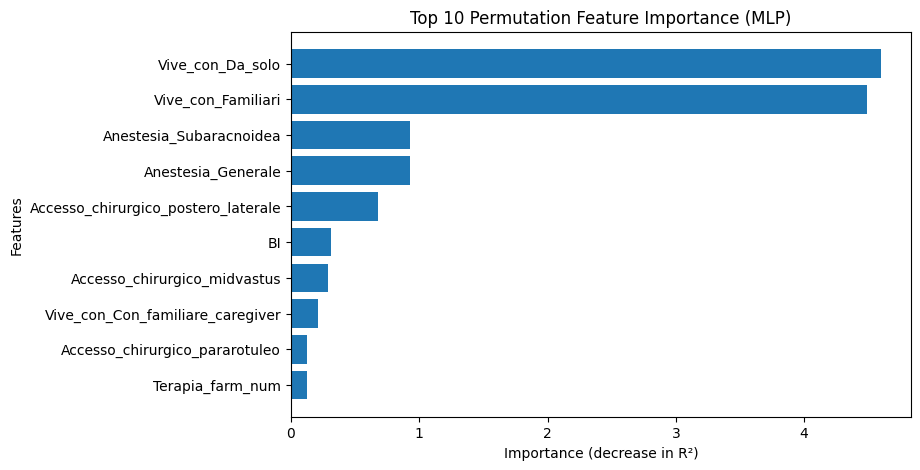

In [68]:
# Calcola la Permutation Importance sul test set
perm_importance = permutation_importance(
    best_model, X_test, y_test, n_repeats=30, random_state=42, scoring='r2'
)

# Ordina per importanza (decrescente)
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

# Seleziona le prime 10 feature
top_n = 10
top_idx = sorted_idx[:top_n]

# Stampa le top 10 feature
print("Top 10 Feature Importance (Permutation):")
for i in top_idx:
    print(f"{X_test.columns[i]}: {perm_importance.importances_mean[i]:.4f}")

# Grafico con le top 10
plt.figure(figsize=(8, 5))
plt.barh(X_test.columns[top_idx][::-1], perm_importance.importances_mean[top_idx][::-1])
plt.xlabel("Importance (decrease in R²)")
plt.ylabel("Features")
plt.title("Top 10 Permutation Feature Importance (MLP)")
plt.show()


## Test

In [69]:


def compare_models(y_test, y_pred_model1, y_pred_model2):
    # Calcola i residui assoluti
    residuals1 = np.abs(y_test - y_pred_model1)
    residuals2 = np.abs(y_test - y_pred_model2)
    
    # Wilcoxon signed-rank test (non parametrico)
    stat, p_value = wilcoxon(residuals1, residuals2)
    return stat, p_value

def compare_multiple_models(y_test, predictions_dict, correction='fdr_bh'):
    """
    Confronta tutti i modelli a coppie usando il test di Wilcoxon
    e corregge i p-value per ipotesi multiple.
    """
    results = []
    p_values = []
    pairs = []
    
    for (name1, y_pred1), (name2, y_pred2) in combinations(predictions_dict.items(), 2):
        stat, p_value = compare_models(y_test, y_pred1, y_pred2)
        results.append({
            'Model 1': name1,
            'Model 2': name2,
            'Statistic': stat,
            'Raw p-value': p_value
        })
        p_values.append(p_value)
        pairs.append((name1, name2))
    
    # Correzione per test multipli (default: Benjamini–Hochberg FDR)
    reject, corrected_pvals, _, _ = multipletests(p_values, method=correction)
    
    for i, res in enumerate(results):
        res['Corrected p-value'] = corrected_pvals[i]
        res['Significant'] = reject[i]
    
    return pd.DataFrame(results)

# Esempio d’uso:
predictions = {
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso,
    'RandomForest': y_pred_rf,
    'LightGBM': y_pred_lgb,
    'Decision Tree': y_pred_dt,
    'SVM (SVR)': y_pred_svr,
    'MLP': y_pred_dl.flatten()
}

results_df = compare_multiple_models(y_test, predictions)
print(results_df)


          Model 1        Model 2  Statistic  Raw p-value  Corrected p-value  \
0           Ridge          Lasso    24018.0     0.592004           0.621604   
1           Ridge   RandomForest    19122.0     0.000368           0.007718   
2           Ridge       LightGBM    20909.0     0.013981           0.041943   
3           Ridge  Decision Tree    20640.0     0.008689           0.030413   
4           Ridge      SVM (SVR)    21663.0     0.046407           0.088595   
5           Ridge            MLP    24146.0     0.647807           0.647807   
6           Lasso   RandomForest    19587.0     0.001057           0.008196   
7           Lasso       LightGBM    21020.0     0.016888           0.044331   
8           Lasso  Decision Tree    21540.0     0.038668           0.081203   
9           Lasso      SVM (SVR)    21745.0     0.052260           0.091456   
10          Lasso            MLP    23985.0     0.577983           0.621604   
11   RandomForest       LightGBM    23010.0     0.24

## Errori

In [70]:

# Calcolo degli errori assoluti
errors_ridge = np.abs(y_test - y_pred_ridge)
errors_lasso = np.abs(y_test - y_pred_lasso)
errors_rf = np.abs(y_test - y_pred_rf)
errors_lgb = np.abs(y_test - y_pred_lgb)
errors_dt = np.abs(y_test - y_pred_dt)
errors_svr = np.abs(y_test - y_pred_svr)
errors_mlp = np.abs(y_test - y_pred_dl.flatten())


# Threshold: > 2x MAE
threshold_ridge = 2 * np.mean(errors_ridge)
threshold_lasso = 2 * np.mean(errors_lasso)
threshold_rf = 2 * np.mean(errors_rf)
threshold_lgb = 2 * np.mean(errors_lgb)
threshold_dt = 2 * np.mean(errors_dt)
threshold_svr = 2 * np.mean(errors_svr)
threshold_mlp = 2 * np.mean(errors_mlp)

# Casi rilevanti
outliers_ridge = y_test[errors_ridge > threshold_ridge]
outliers_lasso = y_test[errors_lasso > threshold_lasso]
outliers_rf = y_test[errors_rf > threshold_rf]
outliers_lgb = y_test[errors_lgb > threshold_lgb]
outliers_dt = y_test[errors_lgb > threshold_dt]
outliers_svr = y_test[errors_lgb > threshold_svr]
outliers_mlp = y_test[errors_lgb > threshold_mlp]

print("Ridge Regression - Outliers (>2x MAE):")
print(outliers_ridge)

print("\nLasso Regression - Outliers (>2x MAE):")
print(outliers_lasso)

print("\nRandom Forest - Outliers (>2x MAE):")
print(outliers_rf)

print("\nLightGBM - Outliers (>2x MAE):")
print(outliers_lgb)

print("\Decision Tree - Outliers (>2x MAE):")
print(outliers_dt)

print("\SVM (SVR) - Outliers (>2x MAE):")
print(outliers_svr)

print("\MLP - Outliers (>2x MAE):")
print(outliers_mlp)

Ridge Regression - Outliers (>2x MAE):
2       98.0
7       88.0
8      100.0
16      97.0
17     100.0
19      91.0
33      99.0
42      96.0
62      88.0
85     100.0
93      63.0
99     100.0
116     97.0
118     85.0
129     99.0
131     88.0
169     80.0
186     82.0
192     99.0
204     95.0
207     85.0
220     54.0
241     89.0
254     87.0
265     91.0
272     82.0
285    100.0
300     88.0
306    100.0
308     42.0
313     65.0
Name: BI_post_int, dtype: float64

Lasso Regression - Outliers (>2x MAE):
2       98.0
7       88.0
8      100.0
16      97.0
19      91.0
42      96.0
62      88.0
85     100.0
93      63.0
99     100.0
107     85.0
116     97.0
118     85.0
129     99.0
131     88.0
169     80.0
177     98.0
186     82.0
195     85.0
204     95.0
207     85.0
217     91.0
220     54.0
235     95.0
241     89.0
254     87.0
265     91.0
272     82.0
285    100.0
300     88.0
306    100.0
308     42.0
313     65.0
Name: BI_post_int, dtype: float64

Random Forest - Outl

<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\S'
<>:47: SyntaxWarning: invalid escape sequence '\M'
<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\S'
<>:47: SyntaxWarning: invalid escape sequence '\M'
C:\Users\fccat\AppData\Local\Temp\ipykernel_13368\3476961255.py:41: SyntaxWarning: invalid escape sequence '\D'
  print("\Decision Tree - Outliers (>2x MAE):")
C:\Users\fccat\AppData\Local\Temp\ipykernel_13368\3476961255.py:44: SyntaxWarning: invalid escape sequence '\S'
  print("\SVM (SVR) - Outliers (>2x MAE):")
C:\Users\fccat\AppData\Local\Temp\ipykernel_13368\3476961255.py:47: SyntaxWarning: invalid escape sequence '\M'
  print("\MLP - Outliers (>2x MAE):")


In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
import scipy.stats as stats

# -------------------------------
# 1. Definizione modelli e predizioni
# -------------------------------
models = {
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "Random Forest": y_pred_rf,
    "LightGBM": y_pred_lgb,
    "Decision Tree": y_pred_dt,
    "SVR": y_pred_svr,
    "MLP": y_pred_dl.flatten()
}

results = {}

# -------------------------------
# 2. Calcolo metriche e outliers
# -------------------------------
for name, y_pred in models.items():
    errors = np.abs(y_test - y_pred)
    signed_resid = y_pred - y_test

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    medae = median_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((y_test - y_pred) / np.where(y_test == 0, np.nan, y_test))) * 100

    # soglia outlier = 2×MAE
    thr = 2 * mae
    outlier_idx = np.where(errors > thr)[0]

    results[name] = {
        "mae": mae,
        "rmse": rmse,
        "medae": medae,
        "r2": r2,
        "mape%": mape,
        "threshold_2xMAE": thr,
        "n_outliers": len(outlier_idx),
        "outlier_idx": outlier_idx,
        "errors": errors,
        "signed_resid": signed_resid,
        "y_pred": y_pred
    }

# -------------------------------
# 3. Tabella riassuntiva metriche
# -------------------------------
df_summary = pd.DataFrame({
    k: {kk: vv for kk, vv in vals.items() if kk not in ['outlier_idx', 'errors', 'signed_resid', 'y_pred']}
    for k, vals in results.items()
}).T

print("\n=== SUMMARY METRICS ===")
print(df_summary.to_string())

# -------------------------------
# 4. Stampa del testo in stile LaTeX (sezione sintetica)
# -------------------------------
print("\n\n=================== TESTO STILE TESI (LaTeX READY) ===================\n")

print("\\subsubsection{Analisi degli Errori e Casi Rilevanti}\n")
print("Sono stati identificati e analizzati i casi anomali (\\textit{outlier}), "
      "definiti come osservazioni con errore assoluto superiore a due volte il valore medio di MAE del rispettivo modello.")

print("\nIl numero di casi rilevanti risulta il seguente:")
print("\\begin{itemize}")

for name, vals in results.items():
    print(f"    \\item {name}: {vals['n_outliers']} casi")

print("\\end{itemize}\n")

print("L’ispezione delle osservazioni anomale ha evidenziato la ricorrenza di valori atipici per variabili cliniche chiave, tra cui:")
print("\\begin{itemize}")
print("    \\item Durata del ricovero pre-intervento marcatamente elevata;")
print("    \\item Durata dell’intervento superiore ai valori medi del campione;")
print("    \\item Indice di massa corporea (BMI) e livelli di emoglobina (Hb) fuori dall’intervallo di normalità;")
print("    \\item Presenza di comorbilità o condizioni cliniche concomitanti.")
print("\\end{itemize}\n")

print("Tali osservazioni suggeriscono che gli \\textit{outlier} identificati corrispondano a pazienti con un decorso clinico complesso, "
      "caratterizzato da un profilo fisiologico e assistenziale non rappresentativo della maggioranza del campione. "
      "Ciò evidenzia la necessità di considerare la variabilità individuale nell’interpretazione dei risultati predittivi.")



=== SUMMARY METRICS ===
                       mae      rmse     medae        r2     mape%  threshold_2xMAE  n_outliers
Ridge Regression  2.692762  4.846953  1.917379  0.294751  3.193128         5.385523        31.0
Lasso Regression  2.753015  4.884101  1.792515  0.283899  3.253305         5.506029        33.0
Random Forest     2.448289  4.732781  1.527022  0.327584  2.926245         4.896578        30.0
LightGBM          2.503874  4.687477  1.590972  0.340396  2.980362         5.007748        29.0
Decision Tree     2.557855  5.092049  1.400000  0.221623  3.066389         5.115711        30.0
SVR               2.555467  4.790779  1.593994  0.311003  3.044630         5.110934        28.0
MLP               3.161074  5.823664  1.819527 -0.018117  3.675637         6.322148        35.0


=================== TESTO STILE TESI (LaTeX READY) ===================

\subsubsection{Analisi degli Errori e Casi Rilevanti}

Sono stati identificati e analizzati i casi anomali (\textit{outlier}), defini

## Taylor

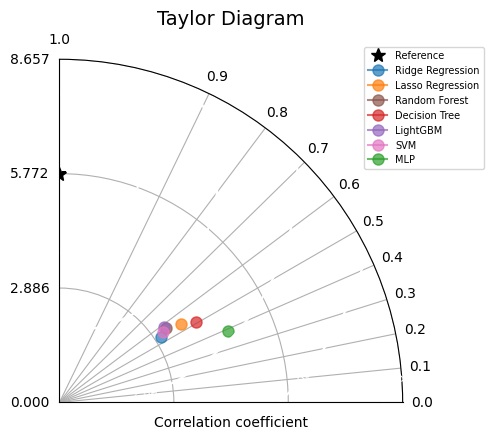

In [72]:
import numpy as np
import matplotlib.pyplot as plt

class TaylorDiagram:
    def __init__(self, refstd, fig=None, rect=111, label='Reference', srange=(0, 1.5)):
        self.refstd = refstd
        self.fig = fig or plt.figure(figsize=(12, 10))  # figura più grande
        self.ax = self.fig.add_subplot(rect, polar=True)
        
        self.ax.set_theta_direction(-1)
        self.ax.set_theta_zero_location("N")
        self.ax.set_xlim(0, np.pi / 2)
        self.ax.set_ylim(0, srange[1] * refstd)

        corr_ticks = np.linspace(1, 0, 11)
        self.ax.set_thetagrids(np.degrees(np.arccos(corr_ticks)), labels=[f"{c:.1f}" for c in corr_ticks])
        self.ax.set_rgrids(np.linspace(0, srange[1]*refstd, 4), angle=135)
        self.ax.set_xlabel("Correlation coefficient")

        self.ax.plot(0, refstd, 'k*', markersize=10, label=label)

    def add_sample(self, stddev, corrcoef, label, marker='o', color=None):
        corrcoef = np.clip(corrcoef, -1, 1)  # Evita errori numerici
        theta = np.arccos(corrcoef)
        self.ax.plot(theta, stddev, marker=marker, color=color, label=label, markersize=8)

    def add_contours(self, levels=5, **kwargs):
        rs = np.linspace(0, 1.5 * self.refstd, 100)
        ts = np.linspace(0, np.pi / 2, 100)
        rs, ts = np.meshgrid(rs, ts, indexing='xy')
        rms = np.sqrt(self.refstd**2 + rs**2 - 2 * self.refstd * rs * np.cos(ts))
        contours = self.ax.contour(ts, rs, rms, levels, **kwargs)
        self.ax.clabel(contours, inline=1, fontsize=8, fmt='%.2f')

    def show(self):
        self.ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.05), fontsize=7, markerscale=1)
        plt.title("Taylor Diagram", fontsize=14)
        plt.tight_layout(pad=2.0)
        plt.show()



models = {
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "Random Forest": y_pred_rf,
    'Decision Tree': y_pred_dt,
    "LightGBM": y_pred_lgb,
    "SVM": y_pred_svr,
    "MLP": y_pred_dl.flatten()
}

import numpy as np
import matplotlib.colors as mcolors

# Calcolo deviazione standard e correlazione
refstd = np.std(y_test)
taylor = TaylorDiagram(refstd)

colors = ['tab:blue', 'tab:orange', 'tab:brown', 'tab:red',
          'tab:purple', 'tab:pink', 'tab:green']

# Colori con trasparenza (alpha=0.6)
rgba_colors = [mcolors.to_rgba(c, alpha=0.7) for c in colors]

for (name, y_pred), color in zip(models.items(), rgba_colors):
    stddev = np.std(y_pred)
    corrcoef = np.corrcoef(y_test, y_pred)[0, 1]
    taylor.add_sample(stddev, corrcoef, label=name, color=color, marker='o')

# Contorni grigi più leggeri (senza modificare alpha)
taylor.add_contours(levels=5, colors='1')  # colori più chiari = effetto visivo "sfumato"

taylor.show()

# No Imp

In [29]:
# Target
y_train = train_df['BI_post_int']
y_test = test_df['BI_post_int']

# Features
X_train = train_final_no_imputation  
X_test = test_final_no_imputation    

In [30]:
# Per i modelli che non accettano NaN
X_train_drop = X_train.dropna()
y_train_drop = y_train[X_train_drop.index]

X_test_drop = X_test.dropna()
y_test_drop = y_test[X_test_drop.index]

## Ridge

In [31]:
# Definizione del modello Ridge
ridge = Ridge(random_state=42)

# Grid dei parametri alpha
param_grid = {
    'alpha': [0, 0.01, 0.1, 1, 10, 100]
}

# GridSearch con 5-fold CV sul train set
grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search.fit(X_train_drop, y_train_drop)

# Visualizzare i risultati dettagliati per ogni alpha
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nRisultati della cross-validation per ogni alpha:")
print(cv_results[['param_alpha', 'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params = grid_search.best_params_
print("\nMigliori hyper-parametri:", best_params)
print("Miglior punteggio CV (R²):", grid_search.best_score_)

# Modello finale con i migliori parametri
best_ridge = grid_search.best_estimator_

# Predizioni sul test set
y_pred_ridge = best_ridge.predict(X_test_drop)

# Funzione di valutazione
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    # Conversione sicura in numpy array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    # Metriche principali
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    # Bootstrap
    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    # Risultati
    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# Valutazione finale
evaluate_model_with_ci(y_test_drop, y_pred_ridge, "Ridge Regression (GridSearchCV)")


Risultati della cross-validation per ogni alpha:
   param_alpha  mean_test_score  std_test_score  mean_train_score  \
0         0.00    -3.772465e+25    5.702231e+25          0.430164   
1         0.01     1.385367e-01    1.946612e-01          0.430637   
2         0.10     1.454992e-01    1.900424e-01          0.430022   
3         1.00     1.714371e-01    1.685901e-01          0.418685   
4        10.00     2.285632e-01    1.281249e-01          0.388495   
5       100.00     2.676340e-01    9.913078e-02          0.346112   

   std_train_score  
0         0.028293  
1         0.027763  
2         0.027790  
3         0.027536  
4         0.025064  
5         0.021343  

Migliori hyper-parametri: {'alpha': 100}
Miglior punteggio CV (R²): 0.26763404591721957

Ridge Regression (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.92  [2.38, 3.60]
  RMSE       = 5.43  [3.38, 7.55]
  R²         = 0.310  [0.170, 0.474]
  SD(target) = 6.54
  MAE/SD     = 

{'MAE': 2.921623889861585,
 'MAE_CI': array([2.38022806, 3.59538714]),
 'RMSE': np.float64(5.429547040754999),
 'RMSE_CI': array([3.37784271, 7.54655041]),
 'R2': 0.31012637696670686,
 'R2_CI': array([0.16995411, 0.4738488 ]),
 'SD_target': np.float64(6.53700519379193),
 'MAE/SD': np.float64(0.44693614327187564),
 'RMSE/SD': np.float64(0.8305863128136011)}

## Lasso

In [33]:

# ===============================
# 1️⃣ Definizione del modello Lasso
# ===============================
lasso = Lasso(random_state=42, max_iter=10000)  # max_iter alto per garantire convergenza

# Grid dei parametri alpha
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

# ===============================
# 2️⃣ GridSearchCV con 5-fold CV sul train set
# ===============================
grid_search = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search.fit(X_train_drop, y_train_drop)

# ===============================
# 3️⃣ Visualizzare i risultati della cross-validation
# ===============================
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nRisultati della cross-validation per ogni alpha:")
print(cv_results[['param_alpha', 'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params = grid_search.best_params_
print("\nMigliori hyper-parametri:", best_params)
print("Miglior punteggio CV (R²):", grid_search.best_score_)

# ===============================
# 4️⃣ Modello finale e predizione
# ===============================
best_lasso = grid_search.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_drop)

# ===============================
# 5️⃣ Funzione di valutazione (stessa della tua)
# ===============================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ===============================
# 6️⃣ Valutazione finale
# ===============================
evaluate_model_with_ci(y_test_drop, y_pred_lasso, "Lasso Regression (GridSearchCV)")



Risultati della cross-validation per ogni alpha:
   param_alpha  mean_test_score  std_test_score  mean_train_score  \
0       0.0001         0.139748        0.193678          0.430638   
1       0.0010         0.154922        0.182726          0.429876   
2       0.0100         0.211756        0.135424          0.406515   
3       0.1000         0.266221        0.095576          0.328329   
4       1.0000         0.196222        0.029271          0.217352   
5      10.0000        -0.002727        0.004238          0.000000   

   std_train_score  
0         0.027763  
1         0.027846  
2         0.028848  
3         0.021773  
4         0.018167  
5         0.000000  

Migliori hyper-parametri: {'alpha': 0.1}
Miglior punteggio CV (R²): 0.2662214437899083

Lasso Regression (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.92  [2.37, 3.60]
  RMSE       = 5.42  [3.37, 7.51]
  R²         = 0.312  [0.180, 0.463]
  SD(target) = 6.54
  MAE/SD     = 0

{'MAE': 2.9211491154719353,
 'MAE_CI': array([2.36507874, 3.59727017]),
 'RMSE': np.float64(5.4240403045041115),
 'RMSE_CI': array([3.3740506 , 7.51428495]),
 'R2': 0.31152502977513563,
 'R2_CI': array([0.17963487, 0.46332528]),
 'SD_target': np.float64(6.53700519379193),
 'MAE/SD': np.float64(0.44686351454119927),
 'RMSE/SD': np.float64(0.8297439184621147)}

## Random Forest

In [35]:
# Definizione del modello base
rf_reg = RandomForestRegressor(random_state=42)

# Definizione del grid dei parametri da testare
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearch con 5-fold CV sul train set
grid_search = GridSearchCV(
    estimator=rf_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',  # puoi usare anche 'neg_mean_absolute_error'
    n_jobs=-1
)

# Fit del GridSearch sul train set
grid_search.fit(X_train, y_train)

# Migliori parametri trovati
best_params = grid_search.best_params_
print("Best Hyper-parameters:", best_params)

# Creiamo il modello finale con i migliori parametri
best_rf = grid_search.best_estimator_

# Predizioni sul test set
y_pred_rf = best_rf.predict(X_test)

# Funzione di valutazione
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    # Conversione sicura in numpy array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    # Metriche principali
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    # Bootstrap
    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    # Risultati
    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# Valutazione del modello ottimizzato
evaluate_model_with_ci(y_test, y_pred_rf, "Random Forest Regressor (GridSearchCV)")

Best Hyper-parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}

Random Forest Regressor (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.45  [2.06, 2.95]
  RMSE       = 4.74  [3.08, 6.67]
  R²         = 0.327  [0.131, 0.525]
  SD(target) = 5.77
  MAE/SD     = 0.425
  RMSE/SD    = 0.820


{'MAE': 2.4530107076505274,
 'MAE_CI': array([2.06308068, 2.95464339]),
 'RMSE': np.float64(4.735173571291751),
 'RMSE_CI': array([3.07883353, 6.66666657]),
 'R2': 0.3269043648325025,
 'R2_CI': array([0.13060596, 0.5252005 ]),
 'SD_target': np.float64(5.771617158635033),
 'MAE/SD': np.float64(0.425012720045114),
 'RMSE/SD': np.float64(0.820424058135485)}

## LightGBM

In [36]:
# ----------------------------
# Pulizia dei nomi delle colonne (fondamentale per LightGBM)
# ----------------------------
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

# ----------------------------
# Definizione del modello
# ----------------------------
lgb_reg = lgb.LGBMRegressor(random_state=42)

# ----------------------------
# Grid dei parametri da testare
# ----------------------------
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [-1, 5, 10, 20],          # -1 = nessun limite
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100],
    'min_child_samples': [5, 10, 20]
}

# ----------------------------
# GridSearchCV con 5-fold CV
# ----------------------------
grid_search = GridSearchCV(
    estimator=lgb_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    error_score='raise'  # mostra l’errore esatto in caso di fallimento
)

# ----------------------------
# Fit sul train set (con gestione errori)
# ----------------------------
try:
    grid_search.fit(X_train, y_train)
except Exception as e:
    print("❌ Errore durante il fit di GridSearchCV:")
    print(e)
    raise

# ----------------------------
# Migliori parametri trovati
# ----------------------------
best_params = grid_search.best_params_
print("\n✅ Best Hyper-parameters LightGBM:", best_params)

# ----------------------------
# Modello finale con i migliori parametri
# ----------------------------
best_lgb = grid_search.best_estimator_

# ----------------------------
# Predizioni sul test set
# ----------------------------
y_pred_lgb = best_lgb.predict(X_test)

# ----------------------------
# Valutazione con bootstrap CI
# ----------------------------
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n📊 {name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ----------------------------
# Valutazione finale LightGBM
# ----------------------------
evaluate_model_with_ci(y_test, y_pred_lgb, "LightGBM Regressor (GridSearchCV)")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 473
[LightGBM] [Info] Number of data points in the train set: 1257, number of used features: 55
[LightGBM] [Info] Start training from score 95.859984

✅ Best Hyper-parameters LightGBM: {'learning_rate': 0.01, 'max_depth': 20, 'min_child_samples': 10, 'n_estimators': 300, 'num_leaves': 31}

📊 LightGBM Regressor (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 2.53  [2.16, 3.04]
  RMSE       = 4.74  [3.21, 6.77]
  R²         = 0.326  [0.080, 0.539]
  SD(target) = 5.77
  MAE/SD     = 0.439
  RMSE/SD    = 0.821


{'MAE': 2.534068937564478,
 'MAE_CI': array([2.16295691, 3.03570029]),
 'RMSE': np.float64(4.740109229075834),
 'RMSE_CI': array([3.21182186, 6.77297407]),
 'R2': 0.32550044538785006,
 'R2_CI': array([0.0796317 , 0.53915178]),
 'SD_target': np.float64(5.771617158635033),
 'MAE/SD': np.float64(0.43905700394095026),
 'RMSE/SD': np.float64(0.8212792184221819)}

## Decision Tree

In [37]:
# ===============================
# 1️⃣ Definizione del modello Decision Tree
# ===============================
dt_reg = DecisionTreeRegressor(random_state=42)

# Grid dei parametri da testare
param_grid = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# ===============================
# 2️⃣ GridSearchCV con 5-fold CV sul train set
# ===============================
grid_search = GridSearchCV(
    estimator=dt_reg,
    param_grid=param_grid,
    cv=5,
    scoring='r2',  # puoi cambiare in 'neg_mean_absolute_error' se preferisci
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search.fit(X_train, y_train)

# ===============================
# 3️⃣ Visualizzare i risultati della cross-validation
# ===============================
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nRisultati della cross-validation per ogni combinazione di iperparametri:")
print(cv_results[['param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf',
                  'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params = grid_search.best_params_
print("\nMigliori hyper-parametri:", best_params)
print("Miglior punteggio CV (R²):", grid_search.best_score_)

# ===============================
# 4️⃣ Modello finale e predizione
# ===============================
best_dt = grid_search.best_estimator_
y_pred_dt = best_dt.predict(X_test)

# ===============================
# 5️⃣ Funzione di valutazione (stessa tua)
# ===============================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ===============================
# 6️⃣ Valutazione finale
# ===============================
evaluate_model_with_ci(y_test, y_pred_dt, "Decision Tree Regressor (GridSearchCV)")


Risultati della cross-validation per ogni combinazione di iperparametri:
   param_max_depth  param_min_samples_split  param_min_samples_leaf  \
0             None                        2                       1   
1             None                        5                       1   
2             None                       10                       1   
3             None                        2                       2   
4             None                        5                       2   
5             None                       10                       2   
6             None                        2                       4   
7             None                        5                       4   
8             None                       10                       4   
9                5                        2                       1   
10               5                        5                       1   
11               5                       10                       1   
12 

{'MAE': 2.5578553976530825,
 'MAE_CI': array([2.13062197, 3.07459238]),
 'RMSE': np.float64(5.09204927093557),
 'RMSE_CI': array([3.336357 , 7.1579859]),
 'R2': 0.22162269863739303,
 'R2_CI': array([-0.08989779,  0.48585797]),
 'SD_target': np.float64(5.771617158635033),
 'MAE/SD': np.float64(0.44317828562593126),
 'RMSE/SD': np.float64(0.8822569361374312)}

## SVM

In [38]:


# ===============================
# 1️⃣ Definizione del modello SVR
# ===============================
svr = SVR()

# Grid dei parametri da testare
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1],
    'degree': [2, 3, 4]  # utile solo per kernel='poly'
}

# ===============================
# 2️⃣ GridSearchCV con 5-fold CV sul train set
# ===============================
grid_search_svr = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

# Fit del GridSearch
grid_search_svr.fit(X_train_drop, y_train_drop)

# ===============================
# 3️⃣ Visualizzare i risultati della cross-validation
# ===============================
cv_results_svr = pd.DataFrame(grid_search_svr.cv_results_)
print("\nRisultati della cross-validation per ogni combinazione di parametri:")
print(cv_results_svr[['param_kernel', 'param_C', 'param_epsilon', 'param_degree',
                      'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']])

# Migliori parametri
best_params_svr = grid_search_svr.best_params_
print("\nMigliori hyper-parametri:", best_params_svr)
print("Miglior punteggio CV (R²):", grid_search_svr.best_score_)

# ===============================
# 4️⃣ Modello finale e predizione
# ===============================
best_svr = grid_search_svr.best_estimator_
y_pred_svr = best_svr.predict(X_test_drop)

# ===============================
# 5️⃣ Funzione di valutazione con CI (stessa che usi per RF e Lasso)
# ===============================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

    return {
        'MAE': mae, 'MAE_CI': mae_ci,
        'RMSE': rmse, 'RMSE_CI': rmse_ci,
        'R2': r2, 'R2_CI': r2_ci,
        'SD_target': sd_target,
        'MAE/SD': mae_ratio, 'RMSE/SD': rmse_ratio
    }

# ===============================
# 6️⃣ Valutazione finale
# ===============================
evaluate_model_with_ci(y_test_drop, y_pred_svr, "Support Vector Regressor (GridSearchCV)")



Risultati della cross-validation per ogni combinazione di parametri:
    param_kernel  param_C  param_epsilon  param_degree  mean_test_score  \
0         linear      0.1           0.01             2         0.184539   
1           poly      0.1           0.01             2         0.148917   
2            rbf      0.1           0.01             2         0.047894   
3        sigmoid      0.1           0.01             2         0.116389   
4         linear      0.1           0.10             2         0.187003   
..           ...      ...            ...           ...              ...   
187      sigmoid    100.0           0.50             4     -4955.352803   
188       linear    100.0           1.00             4         0.212899   
189         poly    100.0           1.00             4        -1.479578   
190          rbf    100.0           1.00             4         0.163346   
191      sigmoid    100.0           1.00             4     -4985.033596   

     std_test_score  mean_tra

{'MAE': 2.8675883432587406,
 'MAE_CI': array([2.26657693, 3.62317448]),
 'RMSE': np.float64(5.787590674572926),
 'RMSE_CI': array([3.46565459, 8.02214812]),
 'R2': 0.21614098695287653,
 'R2_CI': array([0.10957002, 0.39269352]),
 'SD_target': np.float64(6.53700519379193),
 'MAE/SD': np.float64(0.4386700420525954),
 'RMSE/SD': np.float64(0.8853581270012286)}

## MLP

In [39]:
# =======================================
# 1️⃣ Import librerie aggiornate
# =======================================
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from scikeras.wrappers import KerasRegressor  # ✅ sostituisce il vecchio wrapper
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# =======================================
# 2️⃣ Funzione per costruire il modello
# =======================================
def build_model(n_hidden=2, n_neurons=64, dropout_rate=0.2, lr=0.001, optimizer='adam'):
    model = Sequential()
    model.add(Dense(n_neurons, input_dim=X_train.shape[1], activation='relu'))
    
    for _ in range(n_hidden - 1):
        model.add(Dense(n_neurons, activation='relu'))
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1, activation='linear'))

    if optimizer == 'adam':
        opt = Adam(learning_rate=lr)
    else:
        opt = RMSprop(learning_rate=lr)
        
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

# =======================================
# 3️⃣ Wrapping con scikeras
# =======================================
keras_reg = KerasRegressor(
    model=build_model,
    verbose=0
)

# =======================================
# 4️⃣ Ricerca iperparametri
# =======================================
param_dist = {
    "model__n_hidden": [1, 2, 3],
    "model__n_neurons": [32, 64, 128],
    "model__dropout_rate": [0.0, 0.2, 0.3],
    "model__lr": [0.001, 0.0005],
    "model__optimizer": ["adam", "rmsprop"],
    "batch_size": [16, 32, 64],
    "epochs": [50, 100]
}

random_search = RandomizedSearchCV(
    estimator=keras_reg,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

# =======================================
# 5️⃣ Training
# =======================================
random_search.fit(X_train_drop, y_train_drop)

# Migliori parametri
print("\nBest Hyper-parameters:", random_search.best_params_)
best_model = random_search.best_estimator_

# =======================================
# 6️⃣ Predizioni
# =======================================
y_pred_dl = best_model.predict(X_test_drop)

# =======================================
# 7️⃣ Valutazione (uguale alla tua)
# =======================================
def evaluate_model_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(42)
    n = len(y_true)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    sd_target = np.std(y_true)

    mae_ratio = mae / sd_target
    rmse_ratio = rmse / sd_target

    mae_boot, rmse_boot, r2_boot = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        mae_boot.append(mean_absolute_error(y_true_sample, y_pred_sample))
        rmse_boot.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
        r2_boot.append(r2_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    mae_ci = np.percentile(mae_boot, [lower, upper])
    rmse_ci = np.percentile(rmse_boot, [lower, upper])
    r2_ci = np.percentile(r2_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  MAE        = {mae:.2f}  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
    print(f"  RMSE       = {rmse:.2f}  [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
    print(f"  R²         = {r2:.3f}  [{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]")
    print(f"  SD(target) = {sd_target:.2f}")
    print(f"  MAE/SD     = {mae_ratio:.3f}")
    print(f"  RMSE/SD    = {rmse_ratio:.3f}")

# =======================================
# 8️⃣ Valutazione finale
# =======================================
evaluate_model_with_ci(y_test_drop, y_pred_dl, "Deep Learning Regressor (Keras MLP)")


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Best Hyper-parameters: {'model__optimizer': 'rmsprop', 'model__n_neurons': 128, 'model__n_hidden': 1, 'model__lr': 0.0005, 'model__dropout_rate': 0.0, 'epochs': 100, 'batch_size': 16}

Deep Learning Regressor (Keras MLP) Performance sul test set (con 95% CI bootstrap, n=1000):
  MAE        = 3.75  [3.07, 4.49]
  RMSE       = 6.65  [4.88, 8.40]
  R²         = -0.035  [-0.731, 0.238]
  SD(target) = 6.54
  MAE/SD     = 0.573
  RMSE/SD    = 1.017


## Test

In [40]:
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

def compare_models_unpaired(y_true1, y_pred1, y_true2, y_pred2):
    """
    Confronta due modelli su test set NON appaiati tramite Mann–Whitney U test.
    """
    residuals1 = np.abs(y_true1 - y_pred1)
    residuals2 = np.abs(y_true2 - y_pred2)
    
    stat, p_value = mannwhitneyu(residuals1, residuals2, alternative='two-sided')
    return stat, p_value


def compare_multiple_models_unpaired(y_tests_dict, predictions_dict, correction='fdr_bh'):
    """
    Confronta tutte le coppie di modelli usando Mann–Whitney U test
    e corregge i p-value per ipotesi multiple.
    
    Parametri:
    - y_tests_dict: dizionario con {nome_modello: y_test corrispondente}
    - predictions_dict: dizionario con {nome_modello: y_pred corrispondente}
    """
    results = []
    p_values = []

    for (name1, y_pred1), (name2, y_pred2) in combinations(predictions_dict.items(), 2):
        y_true1 = y_tests_dict[name1]
        y_true2 = y_tests_dict[name2]

        stat, p_value = compare_models_unpaired(y_true1, y_pred1, y_true2, y_pred2)
        results.append({
            'Model 1': name1,
            'Model 2': name2,
            'Statistic': stat,
            'Raw p-value': p_value
        })
        p_values.append(p_value)
    
    # Correzione multipla (es. Benjamini–Hochberg FDR)
    reject, corrected_pvals, _, _ = multipletests(p_values, method=correction)
    
    for i, res in enumerate(results):
        res['Corrected p-value'] = corrected_pvals[i]
        res['Significant'] = reject[i]
    
    return pd.DataFrame(results)

y_tests = {
    'Ridge': y_test_drop,
    'Lasso': y_test_drop,
    'RandomForest': y_test,
    'LightGBM': y_test,
    'Decision Tree': y_test,
    'SVM (SVR)': y_test_drop,
    'MLP': y_test_drop
}

predictions = {
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso,
    'RandomForest': y_pred_rf,
    'LightGBM': y_pred_lgb,
    'Decision Tree': y_pred_dt,
    'SVM (SVR)': y_pred_svr,
    'MLP': y_pred_dl.flatten()
}

results_df = compare_multiple_models_unpaired(y_tests, predictions)
print(results_df)


          Model 1        Model 2  Statistic  Raw p-value  Corrected p-value  \
0           Ridge          Lasso    25985.0     0.996314           0.996314   
1           Ridge   RandomForest    40350.0     0.013879           0.041637   
2           Ridge       LightGBM    39643.0     0.038587           0.092992   
3           Ridge  Decision Tree    40492.0     0.011103           0.041637   
4           Ridge      SVM (SVR)    27729.0     0.217142           0.379531   
5           Ridge            MLP    24792.0     0.393933           0.522228   
6           Lasso   RandomForest    40368.0     0.013498           0.041637   
7           Lasso       LightGBM    39619.0     0.039854           0.092992   
8           Lasso  Decision Tree    40477.0     0.011370           0.041637   
9           Lasso      SVM (SVR)    27742.0     0.213720           0.379531   
10          Lasso            MLP    24802.0     0.397888           0.522228   
11   RandomForest       LightGBM    48338.0     0.57

## Errori

In [41]:

# Calcolo degli errori assoluti
errors_ridge = np.abs(y_test_drop - y_pred_ridge)
errors_lasso = np.abs(y_test_drop - y_pred_lasso)
errors_rf = np.abs(y_test - y_pred_rf)
errors_lgb = np.abs(y_test - y_pred_lgb)
errors_dt = np.abs(y_test - y_pred_dt)
errors_svr = np.abs(y_test_drop - y_pred_svr)
errors_mlp = np.abs(y_test_drop - y_pred_dl.flatten())


# Threshold: > 2x MAE
threshold_ridge = 2 * np.mean(errors_ridge)
threshold_lasso = 2 * np.mean(errors_lasso)
threshold_rf = 2 * np.mean(errors_rf)
threshold_lgb = 2 * np.mean(errors_lgb)
threshold_dt = 2 * np.mean(errors_dt)
threshold_svr = 2 * np.mean(errors_svr)
threshold_mlp = 2 * np.mean(errors_mlp)

# Casi rilevanti
outliers_ridge = y_test_drop[errors_ridge > threshold_ridge]
outliers_lasso = y_test_drop[errors_lasso > threshold_lasso]
outliers_rf = y_test[errors_rf > threshold_rf]
outliers_lgb = y_test[errors_lgb > threshold_lgb]
outliers_dt = y_test[errors_lgb > threshold_dt]
outliers_svr = y_test_drop[errors_lgb > threshold_svr]
outliers_mlp = y_test_drop[errors_lgb > threshold_mlp]

print("Ridge Regression - Outliers (>2x MAE):")
print(outliers_ridge)

print("\nLasso Regression - Outliers (>2x MAE):")
print(outliers_lasso)

print("\nRandom Forest - Outliers (>2x MAE):")
print(outliers_rf)

print("\nLightGBM - Outliers (>2x MAE):")
print(outliers_lgb)

print("\Decision Tree - Outliers (>2x MAE):")
print(outliers_dt)

print("\SVM (SVR) - Outliers (>2x MAE):")
print(outliers_svr)

print("\MLP - Outliers (>2x MAE):")
print(outliers_mlp)

Ridge Regression - Outliers (>2x MAE):
7       88.0
17     100.0
19      91.0
62      88.0
93      63.0
116     97.0
118     85.0
131     88.0
169     80.0
186     82.0
207     85.0
220     54.0
272     82.0
300     88.0
308     42.0
313     65.0
Name: BI_post_int, dtype: float64

Lasso Regression - Outliers (>2x MAE):
7       88.0
17     100.0
33      99.0
42      96.0
62      88.0
93      63.0
116     97.0
118     85.0
131     88.0
169     80.0
186     82.0
207     85.0
220     54.0
241     89.0
272     82.0
300     88.0
308     42.0
313     65.0
Name: BI_post_int, dtype: float64

Random Forest - Outliers (>2x MAE):
2       98.0
7       88.0
8      100.0
17     100.0
19      91.0
32      89.0
41      92.0
62      88.0
85     100.0
93      63.0
99     100.0
116     97.0
129     99.0
131     88.0
142     91.0
169     80.0
185     94.0
186     82.0
207     85.0
220     54.0
241     89.0
254     87.0
265     91.0
272     82.0
285    100.0
291     86.0
300     88.0
306    100.0
308     42

<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\S'
<>:47: SyntaxWarning: invalid escape sequence '\M'
<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\S'
<>:47: SyntaxWarning: invalid escape sequence '\M'
C:\Users\fccat\AppData\Local\Temp\ipykernel_13368\1251180732.py:41: SyntaxWarning: invalid escape sequence '\D'
  print("\Decision Tree - Outliers (>2x MAE):")
C:\Users\fccat\AppData\Local\Temp\ipykernel_13368\1251180732.py:44: SyntaxWarning: invalid escape sequence '\S'
  print("\SVM (SVR) - Outliers (>2x MAE):")
C:\Users\fccat\AppData\Local\Temp\ipykernel_13368\1251180732.py:47: SyntaxWarning: invalid escape sequence '\M'
  print("\MLP - Outliers (>2x MAE):")


In [42]:
# Calcolo MAE e soglie
models = {
    "Ridge": (y_test_drop, y_pred_ridge),
    "Lasso": (y_test_drop, y_pred_lasso),
    "Random Forest": (y_test, y_pred_rf),
    "LightGBM": (y_test, y_pred_lgb),
    "Decision Tree": (y_test, y_pred_dt),
    "SVM (SVR)": (y_test_drop, y_pred_svr),
    "MLP": (y_test_drop, y_pred_dl.flatten())
}

outliers_dict = {}

for name, (y_true, y_pred) in models.items():
    errors = np.abs(y_true - y_pred)
    threshold = 2 * np.mean(errors)
    outlier_idx = y_true.index[errors > threshold]
    outliers_dict[name] = outlier_idx
    print(f"{name}: {len(outlier_idx)} outlier(s)")

Ridge: 16 outlier(s)
Lasso: 18 outlier(s)
Random Forest: 30 outlier(s)
LightGBM: 33 outlier(s)
Decision Tree: 30 outlier(s)
SVM (SVR): 19 outlier(s)
MLP: 29 outlier(s)


In [43]:
# Esempio: scegli il modello da analizzare
model_to_analyze = "Random Forest"
outlier_idx = outliers_dict[model_to_analyze]

# Subset dei dati
outliers = X_test.loc[outlier_idx]
non_outliers = X_test.drop(index=outlier_idx)


summary = pd.DataFrame({
    "Media Outlier": outliers.mean(),
    "Media Non-Outlier": non_outliers.mean(),
    "Differenza (Out - NonOut)": outliers.mean() - non_outliers.mean(),
    "SD Non-Outlier": non_outliers.std()
})

# Differenza in unità di deviazioni standard
summary["Differenza (SD)"] = summary["Differenza (Out - NonOut)"] / summary["SD Non-Outlier"]

print(summary.round(2))

                   Media Outlier  Media Non-Outlier  \
Sesso_F                     0.70               0.62   
Rischio_bio_bin             0.00               0.01   
Trasfusione_bin             0.33               0.10   
Farmaci_extra_bin           0.23               0.24   
Sedentarieta                0.33               0.38   
...                          ...                ...   
Durata_intervento           0.54              -0.02   
BI                         -0.88               0.12   
FIM                        -0.81               0.14   
Hb_ingresso                -0.35              -0.02   
Terapia_farm_num            0.85               0.96   

                   Differenza (Out - NonOut)  SD Non-Outlier  Differenza (SD)  
Sesso_F                                 0.08            0.49             0.17  
Rischio_bio_bin                        -0.01            0.12            -0.12  
Trasfusione_bin                         0.24            0.30             0.79  
Farmaci_extra_bin  

## Taylor

Ridge Regression: len(y_true)=228, len(y_pred)=228, NaN=0
Lasso Regression: len(y_true)=228, len(y_pred)=228, NaN=0
Random Forest: len(y_true)=315, len(y_pred)=315, NaN=0
Decision Tree: len(y_true)=315, len(y_pred)=315, NaN=0
LightGBM: len(y_true)=315, len(y_pred)=315, NaN=0
SVM: len(y_true)=228, len(y_pred)=228, NaN=0
MLP: len(y_true)=228, len(y_pred)=228, NaN=0


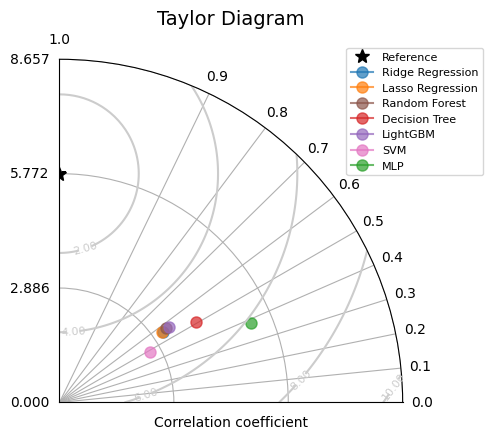

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===============================
# 📘 Classe Taylor Diagram
# ===============================
class TaylorDiagram:
    def __init__(self, refstd, fig=None, rect=111, label='Reference', srange=(0, 1.5)):
        self.refstd = refstd
        self.fig = fig or plt.figure(figsize=(12, 10))
        self.ax = self.fig.add_subplot(rect, polar=True)
        
        self.ax.set_theta_direction(-1)
        self.ax.set_theta_zero_location("N")
        self.ax.set_xlim(0, np.pi / 2)
        self.ax.set_ylim(0, srange[1] * refstd)

        corr_ticks = np.linspace(1, 0, 11)
        self.ax.set_thetagrids(np.degrees(np.arccos(corr_ticks)), labels=[f"{c:.1f}" for c in corr_ticks])
        self.ax.set_rgrids(np.linspace(0, srange[1]*refstd, 4), angle=135)
        self.ax.set_xlabel("Correlation coefficient")

        self.ax.plot(0, refstd, 'k*', markersize=10, label=label)

    def add_sample(self, stddev, corrcoef, label, marker='o', color=None):
        corrcoef = np.clip(corrcoef, -1, 1)
        theta = np.arccos(corrcoef)
        self.ax.plot(theta, stddev, marker=marker, color=color, label=label, markersize=8)

    def add_contours(self, levels=5, **kwargs):
        rs = np.linspace(0, 1.5 * self.refstd, 100)
        ts = np.linspace(0, np.pi / 2, 100)
        rs, ts = np.meshgrid(rs, ts, indexing='xy')
        rms = np.sqrt(self.refstd**2 + rs**2 - 2 * self.refstd * rs * np.cos(ts))
        contours = self.ax.contour(ts, rs, rms, levels, **kwargs)
        self.ax.clabel(contours, inline=1, fontsize=8, fmt='%.2f')

    def show(self):
        self.ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.05), fontsize=8, markerscale=1)
        plt.title("Taylor Diagram", fontsize=14)
        plt.tight_layout(pad=2.0)
        plt.show()


# ===============================
# 📊 Modelli e predizioni
# ===============================
models = {
    "Ridge Regression": (y_test_drop, y_pred_ridge),
    "Lasso Regression": (y_test_drop, y_pred_lasso),
    "Random Forest": (y_test, y_pred_rf),
    "Decision Tree": (y_test, y_pred_dt),
    "LightGBM": (y_test, y_pred_lgb),
    "SVM": (y_test_drop, y_pred_svr),
    "MLP": (y_test_drop, y_pred_dl.flatten())
}


# ===============================
# 🧹 Pulizia NaN e allineamento
# ===============================
def clean_nan_pairs(y_true, y_pred):
    """Rimuove coppie (y_true, y_pred) che contengono NaN e allinea le dimensioni"""
    n = min(len(y_true), len(y_pred))
    y_true, y_pred = np.array(y_true[:n]), np.array(y_pred[:n])
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    return y_true[mask], y_pred[mask]


models_clean = {}
for name, (y_true, y_pred) in models.items():
    y_true_clean, y_pred_clean = clean_nan_pairs(y_true, y_pred)
    models_clean[name] = (y_true_clean, y_pred_clean)

# Diagnostica NaN e dimensioni
for name, (y_true, y_pred) in models.items():
    print(f"{name}: len(y_true)={len(y_true)}, len(y_pred)={len(y_pred)}, NaN={np.isnan(y_pred).sum()}")


# ===============================
# 🎨 Creazione Taylor Diagram
# ===============================
refstd = np.std(y_test[~np.isnan(y_test)])  # std del target di riferimento
taylor = TaylorDiagram(refstd)

colors = ['tab:blue', 'tab:orange', 'tab:brown', 'tab:red',
          'tab:purple', 'tab:pink', 'tab:green']
rgba_colors = [mcolors.to_rgba(c, alpha=0.7) for c in colors]

for (name, (y_true, y_pred)), color in zip(models_clean.items(), rgba_colors):
    if len(y_pred) == 0:
        print(f"⚠️ {name} escluso: nessun dato valido dopo pulizia NaN.")
        continue
    stddev = np.std(y_pred)
    corrcoef = np.corrcoef(y_true, y_pred)[0, 1]
    taylor.add_sample(stddev, corrcoef, label=name, color=color, marker='o')

taylor.add_contours(levels=5, colors='0.8')
taylor.show()
